In [1]:
import pytorch_lightning as pl
import torch
import torch.nn as nn


class SCRNAClassifier(pl.LightningModule):
    def __init__(self, input_dim, num_classes, class_weights=None):
        super().__init__()
        def block(in_dim, out_dim):
            return nn.Sequential(
                nn.Linear(in_dim, out_dim),
                nn.BatchNorm1d(out_dim),
                nn.ReLU(),
                nn.Dropout(0.3)
            )
        
        self.network = nn.Sequential(
            block(input_dim, 512),
            block(512, 256),
            block(256, 128),
            nn.Linear(128, num_classes)
        )
        
        if class_weights is not None:
            self.register_buffer('class_weights', torch.tensor(class_weights, dtype=torch.float32))
        else:
            self.class_weights = None
            
        self.save_hyperparameters()
  
    def forward(self, x):
        return self.network(x)
    
    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = nn.CrossEntropyLoss(weight=self.class_weights)(y_hat, y)
        acc = (y_hat.argmax(1) == y).float().mean()
        self.log('train_loss', loss, prog_bar=True)
        self.log('train_acc', acc, prog_bar=True)
        return loss


    
    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = nn.CrossEntropyLoss(weight=self.class_weights)(y_hat, y)
        acc = (y_hat.argmax(1) == y).float().mean()
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', acc, prog_bar=True)

    
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001)



/home/whalstj1/2025-bioinformatics/202255180/week12/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


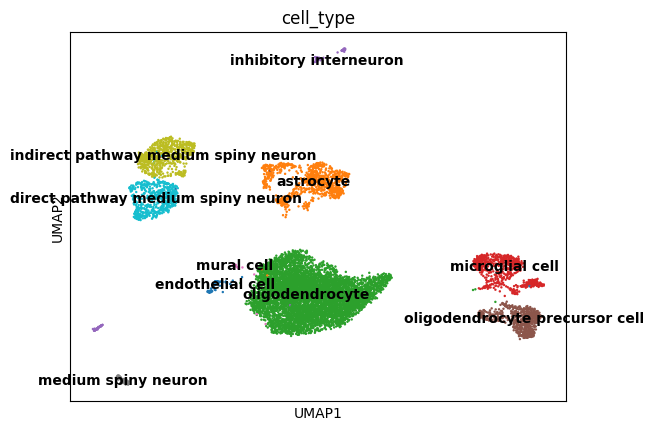

In [2]:
import scanpy as sc
adata = sc.read_h5ad('/bce/lectures/2025-bioinformatics/data/scrnaseq/brain_small.h5ad')

sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
sc.pp.pca(adata, n_comps=50)
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.umap(adata)
sc.pl.umap(adata, color='cell_type', legend_loc='on data')


In [3]:
import numpy as np
np.random.seed(42)
mask = np.random.rand(adata.n_obs) < 0.8
adata.obs['train_mask'] = mask
adata.obs['test_mask'] = ~mask

In [4]:
adata.obs.keys()

Index(['nCount_RNA', 'nFeature_RNA', 'nCount_SCT', 'nFeature_SCT',
       'orig.ident', 'scds.hybrid_score', 'scds.keep', 'percent.mt',
       'miQC.probability', 'miQC.keep', 'dropletQC.nucFrac', 'dropletQC.keep',
       'integrated_snn_res.1', 'seurat_clusters', 'X', 'ID', 'Pair', 'Case',
       'Age', 'BMI', 'PMI', 'pH', 'RIN', 'Tissue.Storage.Time.mo.b', 'Dx_OUD',
       'Dx_Substances', 'Dx_Comorbid', 'Dur.OUD', 'DSM.IV.SUD', 'DSM.IV.Psych',
       'Blood.Toxicology', 'Infxn.Dx', 'Medications.ATODc', 'Tobacco.ATOD',
       'Manner.of.Death', 'Cause.of.Death', 'tissue_ontology_term_id',
       'assay_ontology_term_id', 'disease_ontology_term_id',
       'cell_type_ontology_term_id', 'author_cell_type',
       'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id',
       'donor_id', 'suspension_type', 'is_primary_data',
       'development_stage_ontology_term_id', 'tissue_type', 'cell_type',
       'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity',
       '

In [5]:
adata.obs['train_mask']

GTGGTTAGTAAGTAGT_8      True
GCTACAAGTCTCGACG_8     False
GGATGTTTCACTGGGC_1      True
TCAAGCACACCCTCTA_17     True
GATCACATCCAACTGA_8      True
                       ...  
TGATTTCGTGTCCAAT_1      True
GGGACCTAGGAGAATG_11     True
TGAACGTCAAGCGCAA_9      True
CCGAACGCACGACGCT_18    False
GAACACTTCCACTGGG_7      True
Name: train_mask, Length: 9885, dtype: bool

In [6]:
from sklearn.preprocessing import LabelEncoder
import torch
X, y = adata.obsm["X_pca"], LabelEncoder().fit_transform(adata.obs['cell_type'])
X, y = torch.from_numpy(X), torch.from_numpy(y)

In [7]:
X #pca결과

tensor([[  6.2678,  -2.3103,  -1.9056,  ...,   0.2133,  -1.0467,   0.0681],
        [  6.5218,  -2.2186,  -1.7941,  ...,  -0.8184,  -0.7068,  -0.7954],
        [  3.6829,   7.1840,  23.1716,  ...,  -0.0969,   0.5830,  -0.3004],
        ...,
        [-11.5417,   5.6737,  -1.8849,  ...,  -0.7699,   0.0707,   0.4907],
        [  6.5913,  -2.2923,  -1.4427,  ...,   0.1308,   0.9983,  -0.4207],
        [  6.6286,  -2.1687,  -1.5967,  ...,  -0.6258,   0.4373,   0.0312]])

In [8]:
y # 정답

tensor([8, 8, 6,  ..., 9, 8, 8])

In [9]:
X[mask].size() # train data

torch.Size([7949, 50])

In [10]:
X[~mask].size() # test data

torch.Size([1936, 50])

In [11]:
X_train = X[adata.obs['train_mask'].values]
y_train = y[adata.obs['train_mask'].values]
X_test = X[adata.obs['test_mask'].values]
y_test = y[adata.obs['test_mask'].values]


In [12]:
from torch.utils.data import DataLoader, TensorDataset
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=128, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=128)

In [13]:
# 클래스별 가중치 계산 (inverse frequency)
from sklearn.utils.class_weight import compute_class_weight

y_train_np = y_train.numpy()
num_classes = len(np.unique(y_train_np))

# 클래스별 샘플 수 확인
unique, counts = np.unique(y_train_np, return_counts=True)
print("클래스별 샘플 수:", dict(zip(unique, counts)))

# 'balanced' 방식으로 가중치 계산
class_weights = compute_class_weight('balanced', classes=np.arange(num_classes), y=y_train_np)
print("계산된 클래스 가중치:", class_weights)

클래스별 샘플 수: {np.int64(0): np.int64(697), np.int64(1): np.int64(452), np.int64(2): np.int64(48), np.int64(3): np.int64(506), np.int64(4): np.int64(87), np.int64(5): np.int64(55), np.int64(6): np.int64(523), np.int64(7): np.int64(16), np.int64(8): np.int64(5018), np.int64(9): np.int64(547)}
계산된 클래스 가중치: [ 1.14045911  1.75862832 16.56041667  1.57094862  9.13678161 14.45272727
  1.51988528 49.68125     0.15840972  1.45319927]


In [14]:
from pytorch_lightning.loggers import TensorBoardLogger

trainer = pl.Trainer(max_epochs=50,
    logger=TensorBoardLogger('logs'),
    accelerator='auto',
    devices=[2]) # 훈련에 사용할 GPU 번호 설정
model = SCRNAClassifier(50, num_classes, class_weights=class_weights)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


In [15]:
trainer.fit(model, train_loader, test_loader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]

  | Name    | Type       | Params | Mode 
-----------------------------------------------
0 | network | Sequential | 193 K  | train
-----------------------------------------------
193 K     Trainable params
0         Non-trainable params
193 K     Total params
0.774     Total estimated model params size (MB)
17        Modules in train mode
0         Modules in eval mode


/home/whalstj1/2025-bioinformatics/202255180/week12/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=95` in the `DataLoader` to improve performance.
/home/whalstj1/2025-bioinformatics/202255180/week12/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=95` in the `DataLoader` to improve performance.


Epoch 1: 100%|██████████| 63/63 [00:00<00:00, 101.50it/s, v_num=13, train_loss=0.0116, train_acc=1.000, val_loss=0.160, val_acc=0.997]Epoch 49: 100%|██████████| 63/63 [00:00<00:00, 76.48it/s, v_num=13, train_loss=0.00213, train_acc=1.000, val_loss=0.120, val_acc=0.997]   

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 63/63 [00:00<00:00, 73.34it/s, v_num=13, train_loss=0.00213, train_acc=1.000, val_loss=0.120, val_acc=0.997]


In [16]:
%load_ext tensorboard

In [18]:
%tensorboard --logdir logs --bind_all

Reusing TensorBoard on port 6016 (pid 3569035), started 1 day, 19:45:56 ago. (Use '!kill 3569035' to kill it.)

In [19]:
trainer.save_checkpoint("best_model.ckpt")

In [20]:
model = SCRNAClassifier.load_from_checkpoint("best_model.ckpt")
model.eval()

SCRNAClassifier(
  (network): Sequential(
    (0): Sequential(
      (0): Linear(in_features=50, out_features=512, bias=True)
      (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.3, inplace=False)
    )
    (1): Sequential(
      (0): Linear(in_features=512, out_features=256, bias=True)
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.3, inplace=False)
    )
    (2): Sequential(
      (0): Linear(in_features=256, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.3, inplace=False)
    )
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [21]:
with torch.no_grad():
    y_infer = model(X_test)

In [22]:
y_infer

tensor([[-3.5624, -4.3394, -2.3627,  ..., -1.6171, 10.2619, -4.4559],
        [-5.6883, 13.4408, -3.8026,  ..., -5.0218, -2.5120, -3.7870],
        [-7.4304, -2.5537, -5.2809,  ..., -3.2960, -3.9091, -4.9831],
        ...,
        [-4.8218, -3.4721, -1.4393,  ..., -0.8872,  9.3714, -3.9636],
        [-3.0505, -4.4021, -2.4783,  ..., -2.3105, 10.2235, -4.7629],
        [-3.6700, -3.7985, -2.5004,  ..., -1.7972,  9.7874, -4.3400]])

In [23]:
adata_test = adata[~mask].copy()

y_infer = y_infer.argmax(dim=1).numpy()
y_infer = LabelEncoder().fit(adata.obs['cell_type']).inverse_transform(y_infer)
adata_test.obs['y_infer'] = y_infer

In [24]:
adata_test.obs['y_infer']

GCTACAAGTCTCGACG_8                          oligodendrocyte
TCATACTCATGATAGA_8       direct pathway medium spiny neuron
GGAGCAATCCGTACGG_18    indirect pathway medium spiny neuron
CACTGAACAACCAACT_20                         oligodendrocyte
ACATCGAAGCTAATCC_8                          oligodendrocyte
                                       ...                 
AATGGCTGTGTGATGG_2                          oligodendrocyte
GGGAGTATCGAATCCA_21                               astrocyte
AAACCCAGTCCTTTGC_16                         oligodendrocyte
AGGAGGTCACGGGCTT_13                         oligodendrocyte
CCGAACGCACGACGCT_18                         oligodendrocyte
Name: y_infer, Length: 1936, dtype: object

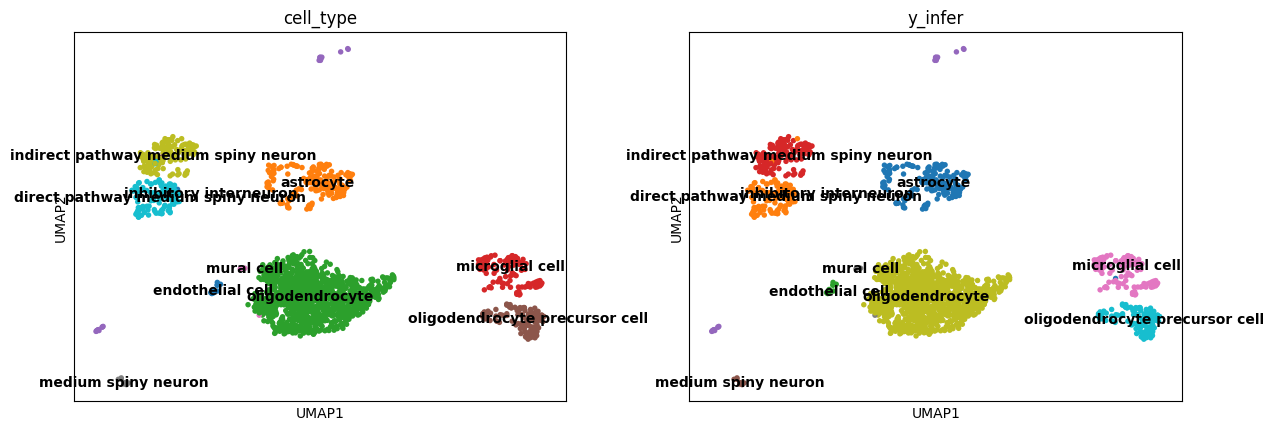

In [25]:
sc.pl.umap(adata_test, color=['cell_type', 'y_infer'], legend_loc='on data')